<a href="https://colab.research.google.com/github/RiaModak/hdc-noise-robustness/blob/main/hdc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== HYPERDIMENSIONAL COMPUTING PIPELINE ANALYSIS ===

[PIPELINE STAGE 1: ENCODING]
-> Raw Input Image Shape: (28, 28) (28x28 matrix with pixel values 0 to 255)
-> After HD Mapping Shape: (10000,) (Successfully projected to a 10,000-dimensional array)
-> Vector 'DIGIT_A' (first 10 bits):    [-1 -1 -1 -1  1  1  1 -1  1  1]
-> Vector 'DIGIT_B' (first 10 bits):    [-1 -1 -1 -1  1  1 -1  1  1 -1]
Initial Similarity: 0.3332 (Nearly Orthogonal/Unrelated)

[PIPELINE STAGE 2: HOLOGRAPHIC BINDING]
-> Math Formula: BOUND_COMBINATION = DIGIT_A * DIGIT_B (Element-wise Multiplication)
-> Bit-by-Bit Multiplication Trace:
   DIGIT_A bits: [-1 -1 -1 -1  1  1  1 -1  1  1]
   DIGIT_B bits: [-1 -1 -1 -1  1  1 -1  1  1 -1]
   RESULT bits : [ 1  1  1  1  1  1 -1 -1  1 -1]   <-- Notice: (-1 * -1 = 1) and (1 * -1 = -1)
-> Does it look like DIGIT_A? similarity:    -0.0034
-> Does it look like DIGIT_B? similarity:    -0.0038
-> Result Analysis: Binding completely scrambled the parent identities into an entirely

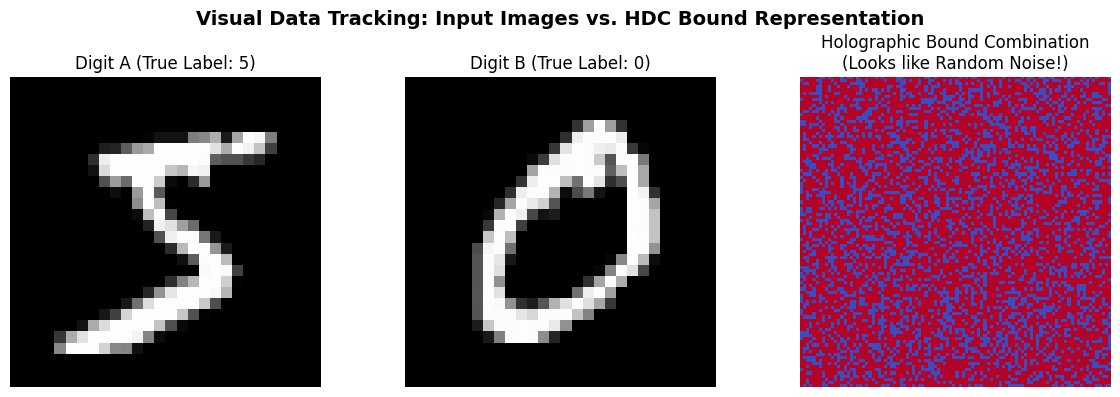


[PIPELINE STAGE 3: NOISE INJECTION]
-> Pristine Vector (first 10 bits): [ 1  1  1  1  1  1 -1 -1  1 -1]
-> Noisy Vector    (first 10 bits): [ 1 -1  1  1  1 -1 -1  1  1 -1] <-- Look closely! Some bits flipped signs.
-> Damage Report: Exactly 30% (3000 out of 10000 indices) were flipped to replicate hardware failure.

[PIPELINE STAGE 4: ASSOCIATIVE MEMORY]
-> Verification Math: Score = (Count of Matching Bits - Count of Flipped Bits) / 10,000
-> Expected Analytical Score: 0.70 (healthy bits) - 0.30 (corrupted bits) = 0.40
-> Calculated Similarity Score: 0.4000
MATCH FOUND (0.4000 > 0.30): Even with 3,000 bad variables, the system recognizes the asset!

[PIPELINE STAGE 5: GENERATING ACCURACY REPORT...]


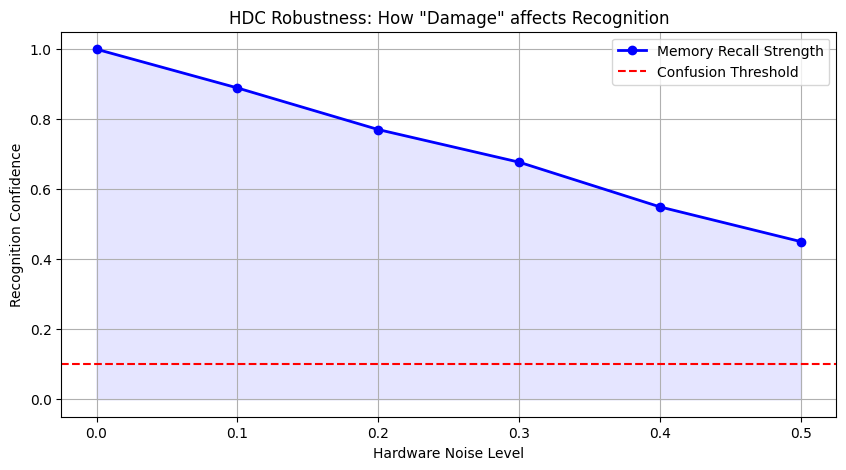

In [ ]:
# =====================================================================
# --- HDC Pipeline testing for 2 data points ---
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load the real dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()


# 1. SETUP
D = 10000
np.random.seed(42)

# Generate a static key-projection matrix to map image pixels to HD space
projection_matrix = np.random.choice([-1, 1], size=(784, D))

def encode_mnist_image(image):
    """Maps a 28x28 grayscale image into a clean 10,000-D bipolar vector."""
    flattened = image.flatten()
    binary_image = (flattened > 127).astype(int)  # Threshold pixels to 0 or 1
    # Project into HD Space and take the sign to make it bipolar (-1, 1)
    return np.sign(np.dot(binary_image, projection_matrix))

def compare(v1, v2):
    return np.dot(v1, v2) / D

print("=== HYPERDIMENSIONAL COMPUTING PIPELINE ANALYSIS ===")

# --- STAGE 1: ENCODING (THE CODEBOOK) ---

print("\n[PIPELINE STAGE 1: ENCODING]")
print(f"-> Raw Input Image Shape: {x_train[0].shape} (28x28 matrix with pixel values 0 to 255)")

digit_A = encode_mnist_image(x_train[0])
digit_B = encode_mnist_image(x_train[1])

print(f"-> After HD Mapping Shape: {digit_A.shape} (Successfully projected to a 10,000-dimensional array)")
print(f"-> Vector 'DIGIT_A' (first 10 bits):    {digit_A[:10]}")
print(f"-> Vector 'DIGIT_B' (first 10 bits):    {digit_B[:10]}")
print(f"Initial Similarity: {compare(digit_A, digit_B):.4f} (Nearly Orthogonal/Unrelated)")


# --- STAGE 2: BINDING (CREATING RELATIONSHIPS) ---
print("\n[PIPELINE STAGE 2: HOLOGRAPHIC BINDING]")
print("-> Math Formula: BOUND_COMBINATION = DIGIT_A * DIGIT_B (Element-wise Multiplication)")
print(f"-> Bit-by-Bit Multiplication Trace:")
print(f"   DIGIT_A bits: {digit_A[:10]}")
print(f"   DIGIT_B bits: {digit_B[:10]}")

bound_combination = digit_A * digit_B

print(f"   RESULT bits : {bound_combination[:10]}   <-- Notice: (-1 * -1 = 1) and (1 * -1 = -1)")
print(f"-> Does it look like DIGIT_A? similarity:    {compare(bound_combination, digit_A):.4f}")
print(f"-> Does it look like DIGIT_B? similarity:    {compare(bound_combination, digit_B):.4f}")
print("-> Result Analysis: Binding completely scrambled the parent identities into an entirely NEW unique concept (Similarity drops to near 0).")

# Insert this right after loading: (x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"-> Look at y_train to find the true identity:")
print(f"   Identity of x_train[0] (Digit A): {y_train[0]}")
print(f"   Identity of x_train[1] (Digit B): {y_train[1]}")

# --- VISUALIZING WHAT THE DATA ACTUALLY LOOKS LIKE ---
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# 1. Plot Digit A
axs[0].imshow(x_train[0], cmap='gray')
axs[0].set_title(f"Digit A (True Label: {y_train[0]})")
axs[0].axis('off')

# 2. Plot Digit B
axs[1].imshow(x_train[1], cmap='gray')
axs[1].set_title(f"Digit B (True Label: {y_train[1]})")
axs[1].axis('off')

# 3. Plot what the "Combined" vector looks like (Reshaped for visualization)
# We take the 10,000-D bound vector and reshape it to a 100x100 grid to view it
# (Note: Execute this line AFTER Stage 2 in your code has defined bound_combination)
try:
    axs[2].imshow(bound_combination.reshape(100, 100), cmap='coolwarm')
    axs[2].set_title("Holographic Bound Combination\n(Looks like Random Noise!)")
except NameError:
    axs[2].text(0.5, 0.5, 'Run Stage 2 First\nto Bind Vectors', ha='center', va='center')
axs[2].axis('off')

plt.suptitle("Visual Data Tracking: Input Images vs. HDC Bound Representation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- STAGE 3: HARDWARE NOISE (THE CHALLENGE) ---
print("\n[PIPELINE STAGE 3: NOISE INJECTION]")
noise_level = 0.30  # 30% Noise
test_vector = bound_combination.copy()
noise_indices = np.random.choice(D, int(D * noise_level), replace=False)
test_vector[noise_indices] *= -1

print(f"-> Pristine Vector (first 10 bits): {bound_combination[:10]}")
print(f"-> Noisy Vector    (first 10 bits): {test_vector[:10]} <-- Look closely! Some bits flipped signs.")
print(f"-> Damage Report: Exactly {int(noise_level*100)}% ({int(D * noise_level)} out of {D} indices) were flipped to replicate hardware failure.")


# --- STAGE 4: ASSOCIATIVE MEMORY (THE CLEAN-UP) ---
print("\n[PIPELINE STAGE 4: ASSOCIATIVE MEMORY]")
print("-> Verification Math: Score = (Count of Matching Bits - Count of Flipped Bits) / 10,000")
print("-> Expected Analytical Score: 0.70 (healthy bits) - 0.30 (corrupted bits) = 0.40")

score = compare(test_vector, bound_combination)
print(f"-> Calculated Similarity Score: {score:.4f}")

if score > 0.3:  # Threshold for recognition
    print(f"MATCH FOUND ({score:.4f} > 0.30): Even with 3,000 bad variables, the system recognizes the asset!")
else:
    print("MATCH FAILED: Noise too high.")


# --- STAGE 5: VISUAL ANALYSIS (THE GRAPH) ---
print("\n[PIPELINE STAGE 5: GENERATING ACCURACY REPORT...]")
noise_range = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
results = [compare(bound_combination, (lambda v, n: (v_copy := v.copy(), v_copy.__setitem__(np.random.choice(D, int(D*n), replace=False), v_copy[np.random.choice(D, int(D*n), replace=False)] * -1), v_copy)[2])(bound_combination, n)) for n in noise_range]

plt.figure(figsize=(10, 5))
plt.plot(noise_range, results, 'b-o', linewidth=2, label='Memory Recall Strength')
plt.fill_between(noise_range, results, color='blue', alpha=0.1)
plt.axhline(y=0.1, color='r', linestyle='--', label='Confusion Threshold')
plt.title('HDC Robustness: How "Damage" affects Recognition')
plt.xlabel('Hardware Noise Level')
plt.ylabel('Recognition Confidence')
plt.legend()
plt.grid(True)
plt.show()

 SYSTEM START: LOADING FULL DATASET & INITIALIZING GLOBAL KEYS
Loading full MNIST dataset...
-> Raw Dataset Loaded: Train Images (60000, 28, 28) | Test Images (10000, 28, 28)
-> Generating static random mapping projection matrix (784 pixels -> 10000 dimensions)...
-> Static Projection Matrix Shape: (784, 10000)

 [EXECUTION PHASE 1: HYPERDIMENSIONAL COMPUTING FRAMEWORK]

[HDC STEP 1: BATCH MAPPING TO HIGH-DIMENSIONAL SPACE]
-> Projecting all 60,000 training images into 10000-D space via matrix multiplication...
-> Success! Converted raw images to HD Array Space. Shape: (60000, 10000)
   Trace of encoded image index 0 (first 15 bits): [-1. -1. -1. -1.  1.  1.  1. -1.  1.  1. -1. -1. -1.  1.  1.]

[HDC STEP 2: HOLOGRAPHIC BUNDLING INTO 10 CLASS DICTIONARY]
-> Squashing continuous sums into permanent bipolar (-1, 1) Master Class Concepts using sign()...

>>> VISUAL LOOK AT THE FINAL 10 DICTIONARY CLASS PROTOTYPE VECTORS (First 12 bits):
   Class Prototype Vector for Digit [0]: [-1. -1. -1

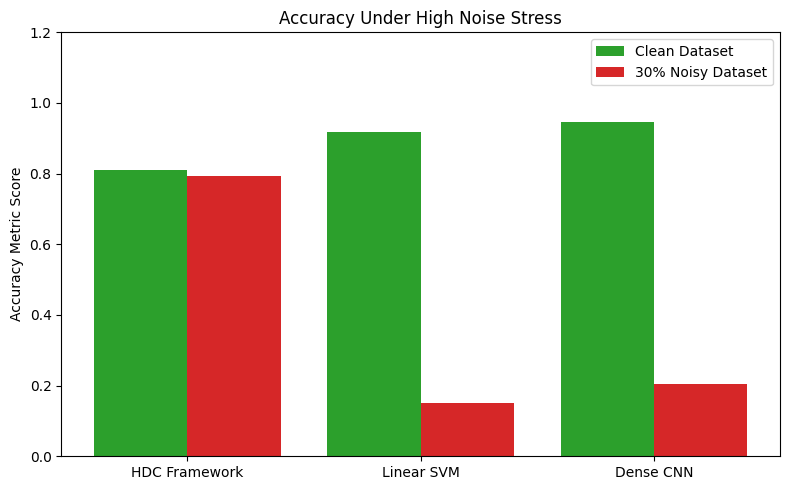

In [ ]:
# =====================================================================
# --- SYSTEMATIC ADDITION: COMPARATIVE TESTING OVER THE SAME DATA ---
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Input
from tensorflow.keras.utils import to_categorical
from sklearn.svm import LinearSVC

# =====================================================================
# --- INITIAL GLOBAL SETUP & DATA LOADING ---
# =====================================================================
print("="*85)
print(" SYSTEM START: LOADING FULL DATASET & INITIALIZING GLOBAL KEYS")
print("="*85)
print("Loading full MNIST dataset...")
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(f"-> Raw Dataset Loaded: Train Images {x_train.shape} | Test Images {x_test.shape}")

D = 10000          # Dimension of Hyperdimensional space
NOISE_LEVEL = 0.30 # 30% Unified Hardware/Pixel Noise Injection
np.random.seed(42)

print(f"-> Generating static random mapping projection matrix ({784} pixels -> {D} dimensions)...")
projection_matrix = np.random.choice([-1, 1], size=(784, D)).astype(np.float32)
print(f"-> Static Projection Matrix Shape: {projection_matrix.shape}")


# =====================================================================
# --- FRAMEWORK 1: HYPERDIMENSIONAL COMPUTING (HDC) ---
# =====================================================================
print("\n" + "="*60)
print(" [EXECUTION PHASE 1: HYPERDIMENSIONAL COMPUTING FRAMEWORK]")
print("="*60)

def encode_hdc_batch(images):
    num_imgs = images.shape[0]
    flattened = images.reshape(num_imgs, 784)
    binary_images = (flattened > 127).astype(np.float32)  # Binarization
    return np.sign(np.dot(binary_images, projection_matrix))

# --- STEP 1: BATCH ENCODING ---
print("\n[HDC STEP 1: BATCH MAPPING TO HIGH-DIMENSIONAL SPACE]")
t_start = time.time()
print(f"-> Projecting all 60,000 training images into {D}-D space via matrix multiplication...")
x_train_hd = encode_hdc_batch(x_train)
print(f"-> Success! Converted raw images to HD Array Space. Shape: {x_train_hd.shape}")
print(f"   Trace of encoded image index 0 (first 15 bits): {x_train_hd[0, :15]}")

# --- STEP 2: HOLOGRAPHIC BUNDLING (CLASS PROTOTYPE GENERATION) ---
print("\n[HDC STEP 2: HOLOGRAPHIC BUNDLING INTO 10 CLASS DICTIONARY]")
# Accumulator bins for our 10 digit dictionary items
class_prototypes = np.zeros((10, D), dtype=np.float32)
for digit in range(10):
    class_mask = (y_train == digit)
    num_samples = np.sum(class_mask)
    # Bundle together all vectors that share the same true digit label
    class_prototypes[digit] = np.sum(x_train_hd[class_mask], axis=0)

print("-> Squashing continuous sums into permanent bipolar (-1, 1) Master Class Concepts using sign()...")
class_prototypes = np.sign(class_prototypes)
hdc_time = time.time() - t_start

print("\n>>> VISUAL LOOK AT THE FINAL 10 DICTIONARY CLASS PROTOTYPE VECTORS (First 12 bits):")
for digit in range(10):
    print(f"   Class Prototype Vector for Digit [{digit}]: {class_prototypes[digit, :12]}")

# --- STEP 3 & 4: NOISE INJECTION & INFERENCE SEARCH ---
print("\n[HDC STEP 3 & 4: TEST DISTORTION & ASSOCIATIVE CLEAN-UP SEARCH]")
print("-> Processing test vectors...")
x_test_hd_clean = encode_hdc_batch(x_test)

print(f"-> Hardware Simulation: Inverting exactly {int(NOISE_LEVEL*100)}% of variables randomly on all test items...")
x_test_hd_noisy = x_test_hd_clean.copy()
for i in range(x_test_hd_noisy.shape[0]):
    noise_indices = np.random.choice(D, int(D * NOISE_LEVEL), replace=False)
    x_test_hd_noisy[i, noise_indices] *= -1

print(f"   Pristine Test Vector 0 (first 10 bits): {x_test_hd_clean[0, :10]}")
print(f"   Corrupted Test Vector 0 (first 10 bits): {x_test_hd_noisy[0, :10]} <-- Flipped variables visible!")

def evaluate_hdc(test_vectors):
    # Compute dot product similarity matrices across all class prototypes simultaneously
    similarity_scores = np.dot(test_vectors, class_prototypes.T) / D
    return np.argmax(similarity_scores, axis=1), similarity_scores

hdc_preds_clean, hdc_scores_clean = evaluate_hdc(x_test_hd_clean)
hdc_preds_noisy, hdc_scores_noisy = evaluate_hdc(x_test_hd_noisy)

print("\n>>> REAL-TIME HDC ASSOCIATIVE SEARCH SCORES (First 3 Test Items):")
for idx in range(3):
    print(f"   Test Item {idx} (True Digit {y_test[idx]}):")
    print(f"     Clean Dataset Similarity Scores vs all 10 classes: {hdc_scores_clean[idx][:5]}...")
    print(f"     Noisy Dataset Similarity Scores vs all 10 classes: {hdc_scores_noisy[idx][:5]}...")
    print(f"     Final System Output Choice -> Clean Pred: {hdc_preds_clean[idx]} | Noisy Pred: {hdc_preds_noisy[idx]}")

acc_hdc_clean = np.mean(hdc_preds_clean == y_test)
acc_hdc_noisy = np.mean(hdc_preds_noisy == y_test)
mem_hdc = (sys.getsizeof(projection_matrix) + sys.getsizeof(class_prototypes)) / 1024
print(f"\n-> HDC Performance Summary: Clean Acc = {acc_hdc_clean*100:.2f}% | Noisy Acc = {acc_hdc_noisy*100:.2f}%")


# =====================================================================
# --- TRADITIONAL MACHINE LEARNING DATA PREPROCESSING ---
# =====================================================================
print("\n" + "="*60)
print(" [PREPROCESSING TRADITIONAL MACHINE LEARNING INPUT ARRAYS]")
print("="*60)
x_train_flat = x_train.reshape(-1, 784) / 255.0
x_test_flat = x_test.reshape(-1, 784) / 255.0

x_train_cnn = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test_cnn = x_test.reshape(-1, 28, 28, 1) / 255.0
y_train_cat = to_categorical(y_train, 10)

print(f"-> Injecting identical {int(NOISE_LEVEL*100)}% pixel values inversion at raw data layers...")
x_test_flat_noisy = x_test_flat.copy()
for i in range(x_test_flat_noisy.shape[0]):
    flip_pixels = np.random.choice(784, int(784 * NOISE_LEVEL), replace=False)
    x_test_flat_noisy[i, flip_pixels] = 1.0 - x_test_flat_noisy[i, flip_pixels]
x_test_cnn_noisy = x_test_flat_noisy.reshape(-1, 28, 28, 1)


# =====================================================================
# --- FRAMEWORK 2: SUPPORT VECTOR MACHINE (LinearSVM) ---
# =====================================================================
print("\n" + "="*60)
print(" [EXECUTION PHASE 2: SUPPORT VECTOR MACHINE (SVM)]")
print("="*60)
t_start = time.time()
svm_model = LinearSVC(dual=False, random_state=42, max_iter=1000)
print("-> Training Linear SVM model over full 60,000 image matrix records...")
svm_model.fit(x_train_flat, y_train)
svm_time = time.time() - t_start
print("-> Optimization solver converged.")

svm_clean_preds = svm_model.predict(x_test_flat[:5])
svm_noisy_preds = svm_model.predict(x_test_flat_noisy[:5])
print("\n>>> REAL-TIME SVM RECOGNITION TRACKING (First 5 Items):")
print(f"   True Targets Labels:  {y_test[:5]}")
print(f"   Clean Predict Class:  {svm_clean_preds}")
print(f"   Noisy Predict Class:  {svm_noisy_preds}")

acc_svm_clean = svm_model.score(x_test_flat, y_test)
acc_svm_noisy = svm_model.score(x_test_flat_noisy, y_test)
mem_svm = sys.getsizeof(svm_model) / 1024
print(f"\n-> SVM Performance Summary: Clean Acc = {acc_svm_clean*100:.2f}% | Noisy Acc = {acc_svm_noisy*100:.2f}%")


# =====================================================================
# --- FRAMEWORK 3: CONVOLUTIONAL NEURAL NETWORK (CNN) ---
# =====================================================================
print("\n" + "="*60)
print(" [EXECUTION PHASE 3: CONVOLUTIONAL NEURAL NETWORK (CNN)]")
print("="*60)
cnn_model = Sequential([
    Input(shape=(28, 28, 1)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("-> Initiating network training loop for 1 epoch over full training sets...")
t_start = time.time()
cnn_model.fit(x_train_cnn, y_train_cat, epochs=1, batch_size=64, verbose=1)
cnn_time = time.time() - t_start

# Evaluate via direct function call pass to bypass tracing warnings
cnn_clean_probs = cnn_model(x_test_cnn[:3], training=False).numpy()
cnn_noisy_probs = cnn_model(x_test_cnn_noisy[:3], training=False).numpy()

print("\n>>> REAL-TIME CNN SOFTMAX CONFIDENCE DISTRIBUTION PROFILE (First 3 Items):")
for idx in range(3):
    print(f"   Test Sample {idx} (True Digit {y_test[idx]}):")
    print(f"     Clean Raw Confidence Arrays: {np.round(cnn_clean_probs[idx][:5], 3)}...")
    print(f"     Noisy Raw Confidence Arrays: {np.round(cnn_noisy_probs[idx][:5], 3)}...")
    print(f"     Argmax Prediction Selection -> Clean: {np.argmax(cnn_clean_probs[idx])} | Noisy: {np.argmax(cnn_noisy_probs[idx])}")

# Final full inference evaluation score metrics extraction
all_cnn_clean_probs = cnn_model(x_test_cnn, training=False).numpy()
all_cnn_noisy_probs = cnn_model(x_test_cnn_noisy, training=False).numpy()
acc_cnn_clean = np.mean(np.argmax(all_cnn_clean_probs, axis=1) == y_test)
acc_cnn_noisy = np.mean(np.argmax(all_cnn_noisy_probs, axis=1) == y_test)
mem_cnn = (cnn_model.count_params() * 4) / 1024
print(f"\n-> CNN Performance Summary: Clean Acc = {acc_cnn_clean*100:.2f}% | Noisy Acc = {acc_cnn_noisy*100:.2f}%")


# =====================================================================
# --- CONSOLIDATED PERFORMANCE DASHBOARD REPORT ---
# =====================================================================
print("\n" + "="*85)
print("                     COMPREHENSIVE GLOBAL SYSTEMS REPORT")
print("="*85)
print(f"{'Performance Metric Parameters':<35} | {'HDC Space':<12} | {'Linear SVM':<12} | {'Dense CNN':<12}")
print("-"*85)
print(f"{'Clean Dataset Accuracy':<35} | {acc_hdc_clean*100:<11.1f}% | {acc_svm_clean*100:<11.1f}% | {acc_cnn_clean*100:<11.1f}%")
print(f"{f'Noise Robustness ({int(NOISE_LEVEL*100)}% Fault Acc)':<35} | {acc_hdc_noisy*100:<11.1f}% | {acc_svm_noisy*100:<11.1f}% | {acc_cnn_noisy*100:<11.1f}%")
print(f"{'Training Phase Execution Time':<35} | {hdc_time:<10.4f}s | {svm_time:<10.4f}s | {cnn_time:<10.4f}s")
print(f"{'Memory Resource Allocation (KB)':<35} | {mem_hdc:<11.2f} | {mem_svm:<11.2f} | {mem_cnn:<11.2f}")
print("="*85)


In [ ]:
models = ['HDC Framework', 'Linear SVM', 'Dense CNN']
fig, ax = plt.subplots(figsize=(8, 5)) # Changed to single subplot

ax.bar(np.array(range(3))-0.2, [acc_hdc_clean, acc_svm_clean, acc_cnn_clean], width=0.4, label='Clean Dataset', color='#2ca02c')
ax.bar(np.array(range(3))+0.2, [acc_hdc_noisy, acc_svm_noisy, acc_cnn_noisy], width=0.4, label=f'{int(NOISE_LEVEL*100)}% Noisy Dataset', color='#d62728')
ax.set_xticks(range(3))
ax.set_xticklabels(models)
ax.set_title('Accuracy Under High Noise Stress')
ax.set_ylabel('Accuracy Metric Score')
ax.set_ylim(0, 1.2)
ax.legend()
plt.tight_layout()
plt.show()